# 03 — Evaluation & Backbone Ablation

**Purpose:** Load the best checkpoint from training (notebook 02), run full
evaluation on BDD100K val set, and report per-class detection mAP + lane IoU.

**Stage 1 deliverable:** Baseline numbers for the YOLOP-style CSP backbone.
These become the reference for Stage 2 ablations.

**Future (Stage 2):** This notebook will be extended to compare backbone swaps
(e.g., CSPDarknet → EfficientNet, ConvNeXt) one variable at a time.

In [1]:
import os, sys
from google.colab import drive
drive.mount('/content/drive')

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing project root: {REPO_ROOT}')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

!python -m pip install -q yacs tqdm opencv-python-headless tensorboard matplotlib
print('repo:', REPO_ROOT)


Mounted at /content/drive
repo: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


In [2]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import torchvision.transforms as T

from lib.config import cfg
from lib.models import get_net
from lib.core import get_loss, validate
from lib.dataset import BddDataset
from lib.utils.drive_dataset import (
    ensure_local_dataset_from_drive,
    find_raw_bdd_root,
    resolve_bdd_images_100k_dir,
    resolve_bdd_labels_100k_dir,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Stage1 default eval target = YOLOPX. Fail loud if the YOLOPX checkpoint
# is missing rather than silently evaluating the older YOLOP baseline.
CONFIG = 'YOLOPX'

yaml_map = {
    'YOLOPX':             os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopx_vehicle_lane_baseline.yaml'),
    'YOLOP':              os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolop_vehicle_lane_baseline.yaml'),
    'YOLOPv2-paper-no-da': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_paper_no_da.yaml'),
    'YOLOPv2-best-row':   os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_best_row.yaml'),
    'YOLOPv2-focal-only': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_focal_only_ablation.yaml'),
}
run_name_map = {
    'YOLOPX':             'yolopx',
    'YOLOP':              'yolop',
    'YOLOPv2-paper-no-da': 'yolopv2_paper_no_da',
    'YOLOPv2-best-row':   'yolopv2_best_row',
    'YOLOPv2-focal-only': 'yolopv2_focal_only',
}

assert CONFIG in yaml_map, f'Unknown CONFIG={CONFIG}. Valid: {list(yaml_map)}'
yaml_path = yaml_map[CONFIG]
assert os.path.exists(yaml_path), f'Missing config YAML: {yaml_path}'

cfg.defrost()
cfg.merge_from_file(yaml_path)

ECOCAR_ROOT = '/content/drive/MyDrive/EcoCAR'
DATASET_ROOT = ensure_local_dataset_from_drive('bdd100k_vehicle5', ECOCAR_ROOT)
RAW_BDD_ROOT = find_raw_bdd_root(ECOCAR_ROOT)
BDD_IMAGES = resolve_bdd_images_100k_dir(RAW_BDD_ROOT, ECOCAR_ROOT)
BDD_LABELS = resolve_bdd_labels_100k_dir(RAW_BDD_ROOT)
cfg.DATASET.ROOT = DATASET_ROOT
cfg.DATASET.DATAROOT = BDD_IMAGES
cfg.DATASET.LABELROOT = BDD_LABELS
cfg.DATASET.LANEROOT = os.path.join(DATASET_ROOT, 'masks')

run_name = run_name_map[CONFIG]
cfg.DRIVE.ROOT = ECOCAR_ROOT
cfg.DRIVE.CHECKPOINT_DIR = os.path.join(ECOCAR_ROOT, 'yolop_vehicle_lane', 'stage1', 'checkpoints', run_name)
cfg.DRIVE.METRICS_DIR    = os.path.join(ECOCAR_ROOT, 'yolop_vehicle_lane', 'stage1', 'metrics',     run_name)

# Notebook 03 must work even when notebook 02 was stopped before 200 epochs.
# In that case the checkpoint can exist, but the metrics/visualization folder
# may not have been created yet. Create the parent directories here before
# validate() tries to save visualization images.
os.makedirs(cfg.DRIVE.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.DRIVE.METRICS_DIR, exist_ok=True)
os.makedirs(os.path.join(cfg.DRIVE.METRICS_DIR, 'visualization'), exist_ok=True)

cfg.TEST.PLOTS = True
cfg.freeze()

print('=' * 64)
print('[Stage1 / 03 eval preflight]')
print(f'  Model family    : {CONFIG}')
print(f'  Model.NAME      : {cfg.MODEL.NAME}')
print(f'  Config YAML     : {yaml_path}')
print(f'  Checkpoint dir  : {cfg.DRIVE.CHECKPOINT_DIR}')
print(f'  Dataset root    : {DATASET_ROOT}')
print(f'  BDD images      : {BDD_IMAGES}')
print(f'  Metrics dir     : {cfg.DRIVE.METRICS_DIR}')
print(f'  NC / classes    : {cfg.MODEL.NC}  {cfg.MODEL.VEHICLE_CLASSES}')
print(f'  Val image size  : {tuple(cfg.TEST.IMAGE_SIZE)}')
print(f'  Dice gain       : {cfg.LOSS.LL_DICE_GAIN}')
print('=' * 64)


Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_vehicle5.tar.gz into this notebook runtime ...
[BDD images] selected: /content/bdd100k_raw/100k | train=70000, val=10000
[Stage1 / 03 eval preflight]
  Model family    : YOLOPX
  Model.NAME      : YOLOPX
  Config YAML     : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/configs/yolopx_vehicle_lane_baseline.yaml
  Checkpoint dir  : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolopx
  Dataset root    : /content/bdd100k_vehicle5
  BDD images      : /content/bdd100k_raw/100k
  Metrics dir     : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx
  NC / classes    : 1  ['vehicle']
  Val image size  : (640, 384)
  Dice gain       : 0.0


In [3]:
# ── Load model + best checkpoint ──
# get_net reads cfg.MODEL.NC and names — do NOT override them.
model = get_net(cfg).to(device)
model.gr = 1.0

ckpt_path = os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'best.pth')
if not os.path.exists(ckpt_path):
    raise FileNotFoundError(
        f'Expected {CONFIG} checkpoint not found: {ckpt_path}\n'
        f'Run notebook 02 first to produce best.pth for the {CONFIG} run.'
    )
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])
print(f'[{CONFIG}] Loaded checkpoint  : {ckpt_path}')
print(f'  epoch={ckpt.get("epoch", "?")}  nc={model.nc}  names={model.names}')
print(f'  best_map={ckpt.get("best_map", "N/A")}, best_ll_iou={ckpt.get("best_ll_iou", "N/A")}')


[YOLOPX] Loaded checkpoint  : /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolopx/best.pth
  epoch=87  nc=1  names=['vehicle']
  best_map=0.8278028747453545, best_ll_iou=0.19587807062477744


In [4]:
# ── Build val dataset ──
# YOLOPv2 paper §3: test letterbox 640×384. Pass an explicit (H, W)
# tuple so BddDataset uses letterbox(auto=False) instead of the
# stride-rounded auto=True path.
val_wh = tuple(getattr(cfg.TEST, 'IMAGE_SIZE', [640, 640]))   # (W, H)
val_size = (int(val_wh[1]), int(val_wh[0]))                   # (H, W)

val_dataset = BddDataset(cfg, is_train=False, inputsize=val_size, transform=T.ToTensor())
val_loader = DataLoader(
    val_dataset, batch_size=cfg.TEST.BATCH_SIZE_PER_GPU,
    shuffle=False, num_workers=4,
    pin_memory=True, collate_fn=val_dataset.collate_fn,
)
sample = val_dataset[0][0].shape
print(f'Val: {len(val_dataset)} samples, letterbox C×H×W = {tuple(sample)}')

[Dataset] split=val | layout=explicit_packaged_like
[Dataset] images=/content/bdd100k_raw/100k/val
[Dataset] labels=/content/bdd100k_raw/100k/val
[Dataset] lanes =/content/bdd100k_vehicle5/masks/val
building database...


100%|██████████| 10000/10000 [00:01<00:00, 9991.43it/s]


database build finish: 10000 samples
missing lane masks skipped: 0
missing detection labels: 0
Val: 10000 samples, letterbox C×H×W = (3, 384, 640)


Writing Stage1 evaluation outputs to: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx


100%|██████████| 313/313 [01:45<00:00,  2.96it/s]


                 all       1e+04    1.08e+05      0.0336       0.931       0.828       0.489
Speed: 2.1/1.6/3.7 ms inference/NMS/total per 640x640 image at batch-size 32
Results saved to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx/visualization

BASELINE RESULTS (YOLOPX)
Detection:
  Precision:   0.0336
  Recall:      0.9305
  mAP@0.5:     0.8278
  mAP@0.5:0.95:0.4893
Lane Segmentation:
  Accuracy:    0.7919
  IoU:         0.1959
  mIoU:        0.5910
Timing:
  Inference:   2.1 ms/img
  NMS:         1.6 ms/img
Val loss:      0.3400


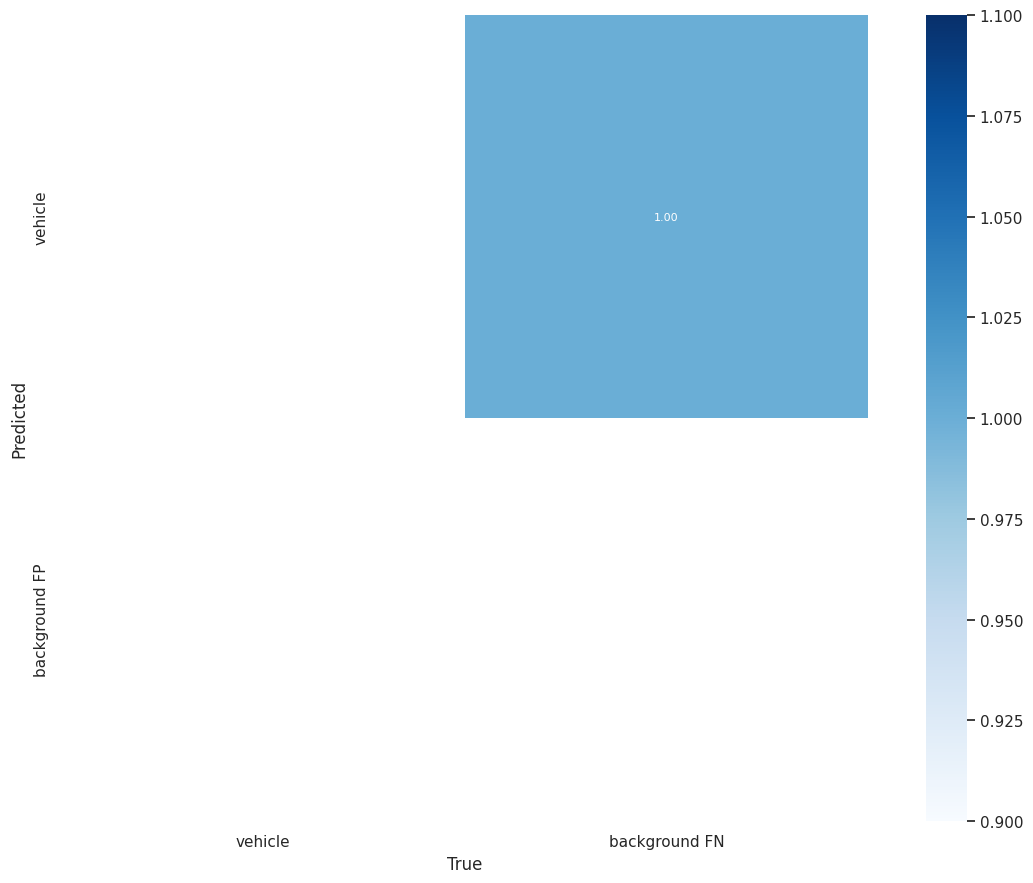

In [5]:
# ── Run evaluation ──
import logging
logger = logging.getLogger('eval')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

criterion = get_loss(cfg, device)
output_dir = cfg.DRIVE.METRICS_DIR
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, 'visualization'), exist_ok=True)
print(f'Writing Stage1 evaluation outputs to: {output_dir}')

ll_seg_result, det_result, val_loss, maps, times = validate(
    epoch=ckpt['epoch'], config=cfg, val_loader=val_loader,
    val_dataset=val_dataset, model=model, criterion=criterion,
    output_dir=output_dir, tb_log_dir='', writer_dict=None,
    logger=logger, device=device
)

ll_acc, ll_iou, ll_miou = ll_seg_result
mp, mr, map50, map_all = det_result

print('\n' + '='*60)
print(f'BASELINE RESULTS ({CONFIG})')
print('='*60)
print(f'Detection:')
print(f'  Precision:   {mp:.4f}')
print(f'  Recall:      {mr:.4f}')
print(f'  mAP@0.5:     {map50:.4f}')
print(f'  mAP@0.5:0.95:{map_all:.4f}')
print(f'Lane Segmentation:')
print(f'  Accuracy:    {ll_acc:.4f}')
print(f'  IoU:         {ll_iou:.4f}')
print(f'  mIoU:        {ll_miou:.4f}')
print(f'Timing:')
print(f'  Inference:   {times[0]*1000:.1f} ms/img')
print(f'  NMS:         {times[1]*1000:.1f} ms/img')
print(f'Val loss:      {val_loss:.4f}')
print('='*60)

In [6]:
# ── Save results for comparison ──
import json

results = {
    'backbone': CONFIG,
    'epoch': ckpt['epoch'],
    'detection': {'precision': float(mp), 'recall': float(mr),
                  'mAP50': float(map50), 'mAP': float(map_all)},
    'lane': {'accuracy': float(ll_acc), 'IoU': float(ll_iou), 'mIoU': float(ll_miou)},
    'val_loss': float(val_loss),
    'inference_ms': float(times[0]*1000),
}

results_path = os.path.join(cfg.DRIVE.METRICS_DIR, 'baseline_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Results saved to {results_path}')

Results saved to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolopx/baseline_results.json
